This notebook plots the solutions. You can actually plot the progress while the solver is running to see if it makes sense.

Various imports:

In [1]:
%load_ext autoreload
%autoreload 2
# add path to code
import sys
sys.path.insert(0, '../source')
import numpy as np
from matplotlib.tri import Triangulation
from matplotlib import colors
import matplotlib.pyplot as plt
import matplotlib as mpl
import topotoolbox as tt3
import json
from netCDF4 import Dataset

In [2]:
# get dem for topotoolbox plotting
dem = tt3.read_tif('store_dem_plotting.tif')
fd = tt3.FlowObject(dem)
s   = tt3.StreamObject(fd,threshold=2000,units='pixels')

# Set default major tick width for x-axis
mpl.rcParams['xtick.major.width'] = 2
mpl.rcParams['xtick.major.size'] = 4


# Set default major tick width for y-axis
mpl.rcParams['ytick.major.width'] = 2
mpl.rcParams['ytick.major.size'] = 4

In [3]:
#choose which results to load
results_name = '../results/store_lakedrain'
t = np.load(results_name+'/t.npy')
nodes_x = np.load(results_name+'/nodes_x.npy')/1e3
nodes_y = np.load(results_name+'/nodes_y.npy')/1e3
dofmap = np.load(results_name+'/dofmap.npy')
triang = Triangulation(nodes_x,nodes_y,dofmap)

# load results
N = np.load(results_name+'/N.npy')
b = np.load(results_name+'/b.npy')
qx = np.load(results_name+'/qx.npy')
qy = np.load(results_name+'/qy.npy')

outflow_dofs = np.load(results_name+'/outflow_dofs.npy')
boundary_coords = np.load(results_name+'/boundary_coords.npy')/1e3
outflow_coords = np.load(results_name+'/outflow_coords.npy')/1e3
inflow_coords = np.load(results_name+'/inflow_coords.npy')/1e3


# get water flow speed
q_m = np.sqrt(qx**2+qy**2)

with open(results_name+"/model_config.json", "r") as f:
    model_config = json.load(f)

outflow_on = model_config['outflow_on']
N_bdry = model_config['N_bdry']
x_min = model_config['x_min']/1e3
x_max = model_config['x_max']/1e3
y_min = model_config['y_min']/1e3
y_max = model_config['y_max']/1e3

# lake site
x_l = model_config['x_l']/1e3
y_l = model_config['y_l']/1e3

N_mean = np.zeros(t.size)
b_mean = np.zeros(t.size)
q_mean = np.zeros(t.size)

j_max=0
for j in range(t.size):
    if np.max(q_m[j,:]>1e-10):
        N_j = N[j,:]
        b_j = b[j,:]
        q_j = q_m[j,:]

        N_mean[j] = np.mean(N_j)
        b_mean[j] = np.mean(b_j)
        q_mean[j] = np.mean(q_j)

        j_max+=1 

j_max -= 1


In [4]:
ds = Dataset('/Users/agstubbl/Desktop/ICESat-2/ATL14_GL_0325_100m_004_05.nc')

x = ds['x'][:]              # x coordinate array (m)
y = ds['y'][:]              # y coordinate array (m)
mask = ds['ice_area'][:].mask

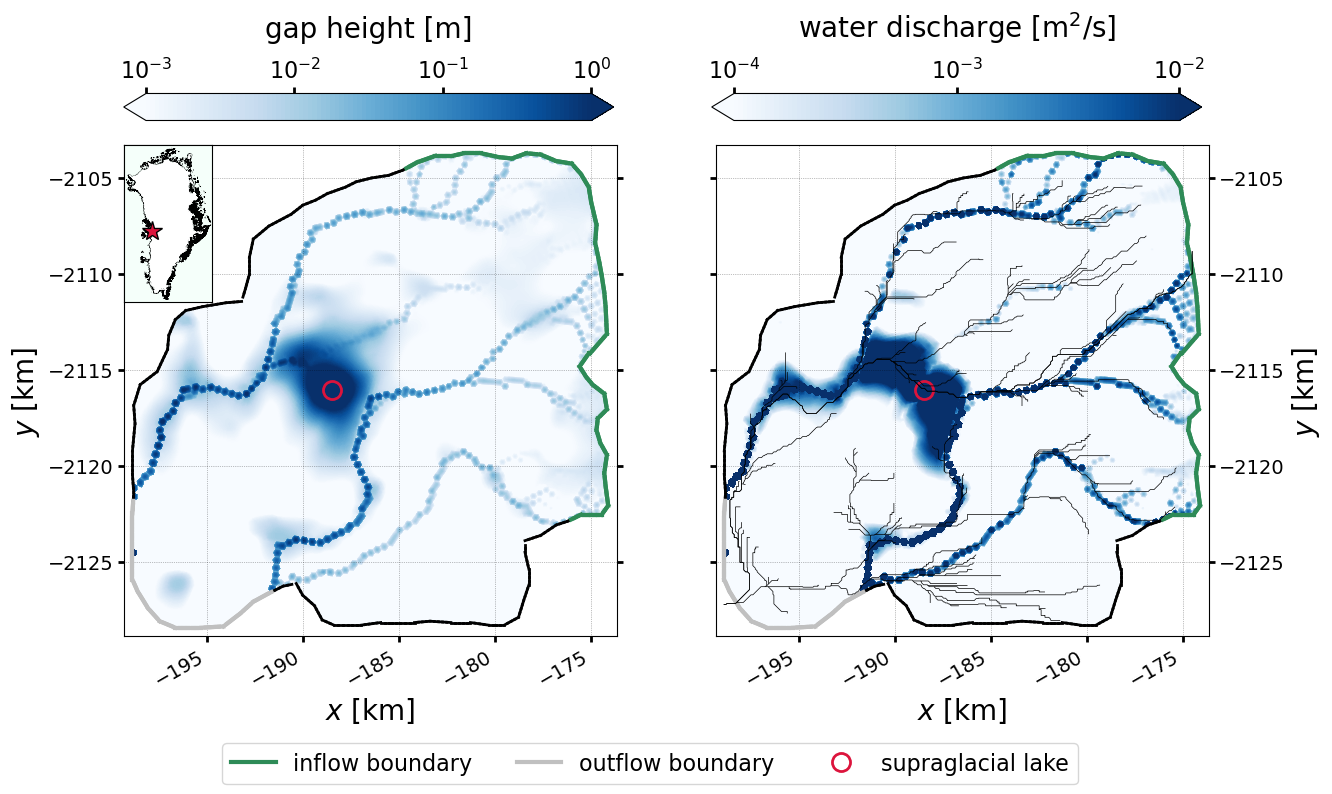

In [5]:
# choose to plot a single timestep OR a sequence to make a movie
ind = [j_max]               # plot a single time step
# ind = np.arange(1,j_max,1) # plot every time step for saving a movie

# make clean movie directory
# !rm -rf {results_name}/movie
# !mkdir {results_name}/movie

j=0

if len(ind)>1:
# use agg backend for saving pngs
    mpl.use('agg')
else:
    %matplotlib inline

qlim2 = -2
qlim1 = -4 

blim2 = 0
blim1 = -3

Nlim = 1

t_scale = 1.0 # 1 for years, 365 for days
if int(t_scale)==365:
    t_str = 'd' 
elif int(t_scale)==1:
    t_str = 'yr'

res_lim = 1

for i in ind:
    print('saved image '+str(j+1)+' out of '+str(len(ind))+' \r',end='')
    
    fig = plt.figure(figsize=(14,12))
    

    ax1 = plt.subplot(121)
    plt.grid(alpha=0.5,linestyle=':',color='k',linewidth=0.5)
    N_i = N[i]
    b_i = b[i]
    for coords in boundary_coords:
        if (np.abs(coords[1,0]-coords[0,0])< res_lim):
            plt.plot(coords[:, 0], coords[:, 1], color='black',linewidth=2)
    for coords in outflow_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            plt.plot(coords[:, 0], coords[:, 1], color='silver',linewidth=3)
    
    for coords in inflow_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            plt.plot(coords[:, 0], coords[:, 1], color='seagreen',linewidth=3)
    
    # p1 = plt.tricontourf(triang,N_i/1e6,levels=np.linspace(0,Nlim,100),cmap='Purples',extend='both')
    p2 = plt.tricontourf(triang,b_i,cmap='Blues',extend='both',norm=colors.LogNorm(),levels=np.logspace(blim1,blim2,100))
    
    

    plt.xlim(x_min,x_max)
    plt.ylim(y_min,y_max)
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel(r'$x$ [km]',fontsize=20)
    plt.ylabel(r'$y$ [km]',fontsize=20)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.plot([x_l],[y_l],marker='o',markersize=13,markeredgewidth=2,color='crimson',fillstyle='none')
    plt.setp(ax1.get_xticklabels(), rotation=30, horizontalalignment='right')
    plt.gca().tick_params(axis='y', which='both', labelright=False, right=True)
    cbar_ax = fig.add_axes([0.125, 0.72, 0.35, 0.0225])
    # cbar = plt.colorbar(p1,orientation='horizontal',ticks=np.linspace(0,Nlim,6),cax=cbar_ax)
    cbar = plt.colorbar(p2,cax=cbar_ax,orientation='horizontal',ticks=np.logspace(blim1,blim2,1+int(np.abs(blim2-blim1))))
    cbar.set_label(r'gap height [m]',fontsize=20,labelpad=15)
    cbar.ax.tick_params(labelsize=16)
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')
    
    # inset axis, comment out to plot faster
    axins = ax1.inset_axes([-0.02, 0.68, 0.22, 0.32], xticks=[],yticks=[],xticklabels=[], yticklabels=[])
    axins.contour(x/1e3,y/1e3,mask,colors='k',levels=[0,1],linewidths=0.2)
    axins.contourf(x/1e3,y/1e3,mask,colors='mintcream',levels=[0.9,1.1])
    axins.plot([x_l],[y_l],marker='*',markersize=15,color='crimson',markeredgecolor='k')
    axins.set_aspect('equal', 'box')

    ax3 = plt.subplot(122)
    plt.grid(alpha=0.5,linestyle=':',color='k',linewidth=0.5)
    q_i = q_m[i]
   
    
    for coords in boundary_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            plt.plot(coords[:, 0], coords[:, 1], color='black',linewidth=2)
    
    flag_0 = 0         
            
    for coords in inflow_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            if flag_0 == 0:
                plt.plot(coords[:, 0], coords[:, 1], color='seagreen',linewidth=3,label=r'inflow boundary')
                flag_0 += 1
            else:
                plt.plot(coords[:, 0], coords[:, 1], color='seagreen',linewidth=3)
              
    flag_0 = 0
    for coords in outflow_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            if flag_0 == 0:
                plt.plot(coords[:, 0], coords[:, 1], color='silver',linewidth=3,label=r'outflow boundary')
                flag_0 += 1
            else:
                plt.plot(coords[:, 0], coords[:, 1], color='silver',linewidth=3)
  
            
    p2 = plt.tricontourf(triang,q_i,cmap='Blues',extend='both',norm=colors.LogNorm(),levels=np.logspace(qlim1,qlim2,100))
    plt.plot([x_l],[y_l],marker='o',linewidth=0,markersize=13,markeredgewidth=2,color='crimson',fillstyle='none',label=r'supraglacial lake')

    plt.xlim(x_min,x_max)
    plt.ylim(y_min,y_max)
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel(r'$x$ [km]',fontsize=20)
    plt.gca().yaxis.set_label_position("right")
    plt.gca().yaxis.tick_right()
    plt.ylabel(r'$y$ [km]',fontsize=20)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.gca().tick_params(axis='y', which='both', labelleft=False, left=True)
    plt.legend(fontsize=16,loc=(-1,-0.3),ncol=3)
    #------- stream plot ------------
    xtix = ax3.get_xticks()
    ytix = ax3.get_yticks()
    xlim = ax3.get_xlim()
    ylim = ax3.get_ylim()

    dem.plot(ax3,cmap="terrain",alpha=0) 
    (s.klargestconncomps(1)).plot(ax=ax3,color='k',linewidth=0.5)
    (s.klargestconncomps(1).trunk()).plot(ax=ax3,color='k',linewidth=0.5)
    ax3.invert_yaxis()
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    ax3.tick_params(axis='y', which='both', labelleft=False, left=True)
    ax3.set_xticks(xtix)
    ax3.set_yticks(ytix)
    ax3.set_xlim(xlim)
    ax3.set_ylim(ylim)
    plt.setp(ax3.get_xticklabels(), rotation=30, horizontalalignment='right')

    #-------------------------------
    cbar_ax = fig.add_axes([0.545, 0.72, 0.35, 0.0225])
    cbar = plt.colorbar(p2,cax=cbar_ax,orientation='horizontal',ticks=np.logspace(qlim1,qlim2,1+int(np.abs(qlim2-qlim1))))#,format='%.0e')
    cbar.set_label(r'water discharge [m$^2/$s]',fontsize=20,labelpad=15)
    cbar.ax.tick_params(labelsize=16)
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')


    if len(ind)>1:
        plt.savefig('{}/movie/movie_'.format(results_name)+str(j),bbox_inches='tight')
    if len(ind)==1:
        plt.savefig('store_fig',bbox_inches='tight')
        plt.show()
    plt.close()
    j+=1